In [56]:
%load_ext autoreload
%autoreload 2


In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [48]:
from preprocessing import (
    load_data,
    numeric_categorical_features
)

In [54]:
from EDA import (
    type_shape_stats,
    descriptive_stats,
    missing_values_summary,
    features_correlation
)

In [9]:
raw_df = load_data("data/bank-additional-full.csv")
raw_df.head()

/Users/yurkevychann/Desktop/Portfolio/Mid-term project/MLmodels-/Portuguese client term deposit subscription/preprocessing.py:28: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  """


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


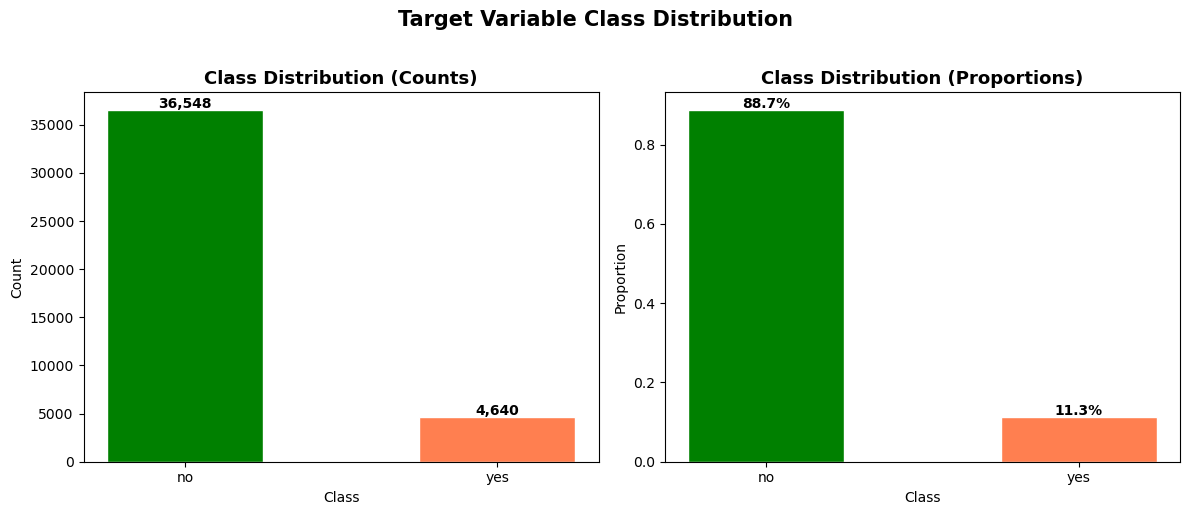

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot of counts
counts = raw_df['y'].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=['green', 'coral'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values): # calculates count for bars
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Bar plot of proportions
proportions = raw_df['y'].value_counts(normalize=True)
axes[1].bar(proportions.index.astype(str), proportions.values, color=['green', 'coral'], edgecolor='white', width=0.5)
axes[1].set_title('Class Distribution (Proportions)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Proportion')
for i, v in enumerate(proportions.values): # calculates percentages
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

plt.suptitle('Target Variable Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The a barplot of target variable distribution values shows that there is a severe class imbalance in target variable. 
This implies that later I need to use techniques to handle class imbalance. Possible options of which I can think of now is:  resampling techniques(SMOTE, SMOTENC, SMOTEN, SMOTE-Tomek) and  assigning class weights to the model: attribute `class_weights='balanced'`. 

The class imbalance effects a few aspects: performance evaluation metrics and dataset splitting into train/test data (for efficient training `stratified` should be applied, so I keep the ration between classes distributions in sets: training/test set has the same class distribution as the original data).


## Evaluation metrics

Class imbalance matters in the performance evaluation because accuracy becomes misleading(model can be excellent at predicting the mejority class, but failing to predict the minority class). Based on that: Precision, Recall, F1-score and AUC-ROC plot is a great choice. I picked AUC-ROC as metric to compare one model with another because it helps to see how well model separates two classes. 

The main metric I chose is F1-score because it's the appropriate metric for data with class imbalance: harmonic mean of precision and recall. Additional metrics precision and recall I chose in order to be able to interpret F1-score and identify type of errors my model makes(precision will show how many predicted positives are correct and recall will help to identify the true positive).

## Shape and data types

In [12]:
type_shape_stats(raw_df)

dataframe shape: (41188, 21)
dataframe types: age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


Dataset has 20 features and 1 target variable (which is term deposit subscription) and 41188 rows.

There are three types of data: float, integer and categorical. I decided to note that target variable is the categorical variable which I will encode to numeric: `no` is `0` and `yes` is `1`. 

## Decriptive statistics of variables
 mean, standard deviation, min/max, mode, quartiles

In [13]:
descriptive_stats(raw_df)

                  count         mean         std       min       25%  \
age             41188.0    40.024060   10.421250    17.000    32.000   
duration        41188.0   258.285010  259.279249     0.000   102.000   
campaign        41188.0     2.567593    2.770014     1.000     1.000   
pdays           41188.0   962.475454  186.910907     0.000   999.000   
previous        41188.0     0.172963    0.494901     0.000     0.000   
emp.var.rate    41188.0     0.081886    1.570960    -3.400    -1.800   
cons.price.idx  41188.0    93.575664    0.578840    92.201    93.075   
cons.conf.idx   41188.0   -40.502600    4.628198   -50.800   -42.700   
euribor3m       41188.0     3.621291    1.734447     0.634     1.344   
nr.employed     41188.0  5167.035911   72.251528  4963.600  5099.100   

                     50%       75%       max  
age               38.000    47.000    98.000  
duration         180.000   319.000  4918.000  
campaign           2.000     3.000    56.000  
pdays            99

Conclusions I made and I want to investigate further:

1. `Duration` has mean = `258` while having the max value of `4918`. This implies a possiblity of outliers(I will plot a boxplot to investigate it more). 

2. `Campaign` has mean = `2` while the maximum value is `56`. (I will plot a boxplot to detect outliers for this variable too). 

3. `pdays` has suspicious distribution of data: 75% of the data is 999 (three quartiles have the same value = 999). I will plot the distribution of values for that variable to see why 75% of the data is 999 and how it affects target variable. 

4. `previous` has mean `0.17`, but 25%, 50%, 75% is `0`, while the maximum value is `7`. (I want to know what is the distribution of previous and how it's connected to the target variable).



<Axes: xlabel='y', ylabel='duration'>

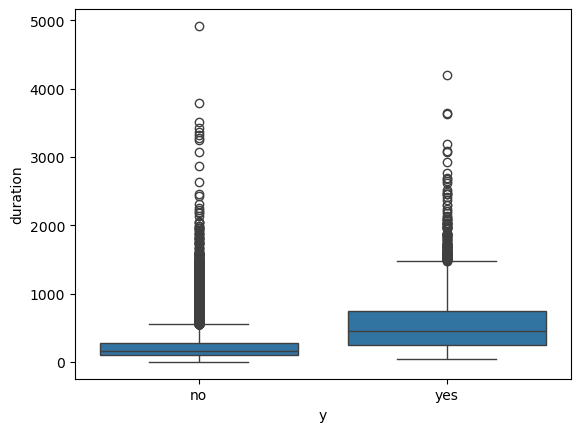

In [41]:
sns.boxplot(x='y', y='duration', data=raw_df)


Looking at boxplots of duration and target, I can see that there are a lot of outliers. 

I use IQR(Interquartile Range) to detect outliers and to actually have some evidence that there are outliers besides just a boxplot. 



In [43]:
# Calculate Interquartile Range (IQR)
q1 = np.percentile(raw_df['duration'], 25)
q3 = np.percentile(raw_df['duration'], 75)
iqr = q3 - q1

# Calculate Quartile Deviation
quartile_deviation = (q3 - q1) / 2

print("Interquartile Range (IQR):", iqr)
print("Quartile Deviation:", quartile_deviation)

Interquartile Range (IQR): 217.0
Quartile Deviation: 108.5


## Duration feature analysis
I decided not to use `Duration` as input feature for the machine learning models because it will cause data leakage: duration of the call is known only after the call ends and not during the call. Large values mean long duration calls. 

I will not use IQR to remove outliers because of the reason that longer calls mean longer engagement and outliers actually contain informative datapoints.

I consider `Duration` as predictible variable because if a person just hung up that means that most likely a person wasn't interested and said no, thus durating of the call is low. The model can just learn that high duration of the call is yes and low duration is no. 
And the boxplots I plotted already show it. 

I will use duration in order to see how model performance changes when I introduce the data leakage variable. It will be a separate experiment where one model I will test with input features excluding `Duration` and the other with `Duration`. 

It will show how misleading results will be if data leakage variable is included in the model. This will show how the model I developed relies on unavailable information. 

## Campaign variable analysis

<Axes: xlabel='y', ylabel='campaign'>

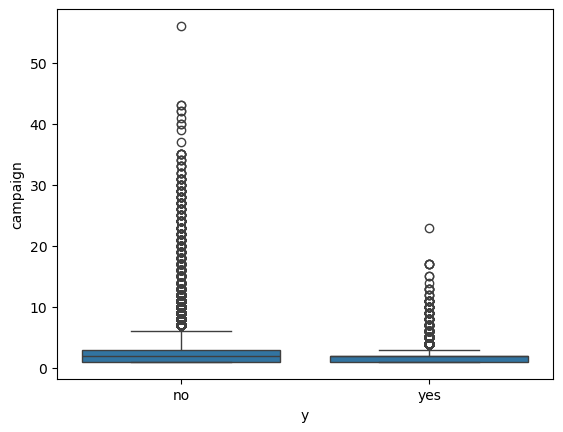

In [44]:
sns.boxplot(x='y', y='campaign', data=raw_df)

In [45]:
# Calculate Interquartile Range (IQR)
q1 = np.percentile(raw_df['campaign'], 25)
q3 = np.percentile(raw_df['campaign'], 75)
iqr = q3 - q1

# Calculate Quartile Deviation
quartile_deviation = (q3 - q1) / 2

print("Interquartile Range (IQR):", iqr)
print("Quartile Deviation:", quartile_deviation)

Interquartile Range (IQR): 2.0
Quartile Deviation: 1.0


<Axes: >

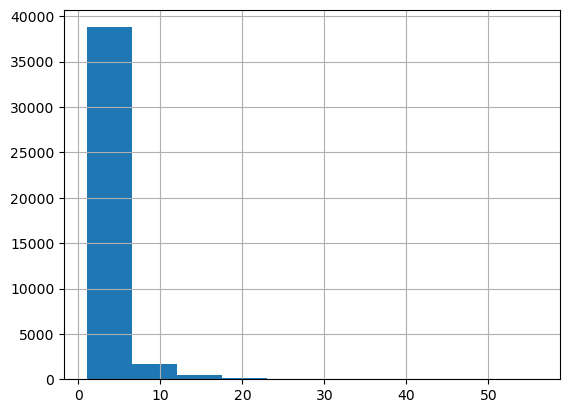

In [46]:
raw_df['campaign'].hist()

The distribution of `campaign` is right-skewed. Most values are concetrated between 1 and 3 and a small number of large values: most people were contacted a few times, but a few people were contacted many times.

I decided not to do anything with outliers in `campaign` because outliers don't introduce noise in that case: outliers mean a few people have been contacted a lot of times. 

In [26]:
(raw_df['pdays'] == 999).mean()

np.float64(0.9632174419733903)

In [34]:
raw_df['pdays'].value_counts().head()

pdays
999    39673
3        439
6        412
4        118
9         64
Name: count, dtype: int64

In [ ]:
raw_df['duration'].value_counts().head()

<Axes: >

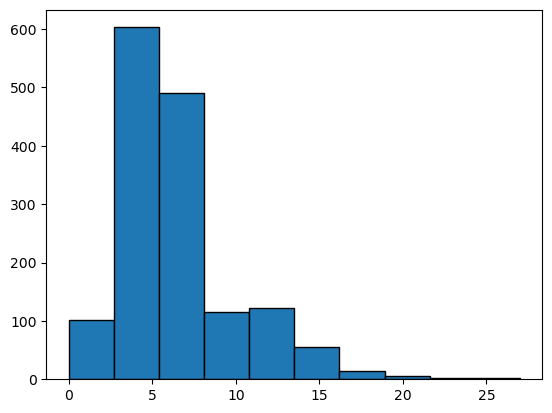

In [28]:
# distribution of pdays excluding 999 value
raw_df[raw_df['pdays'] != 999]['pdays'].hist(edgecolor='black', grid=False)

<Axes: xlabel='y', ylabel='pdays'>

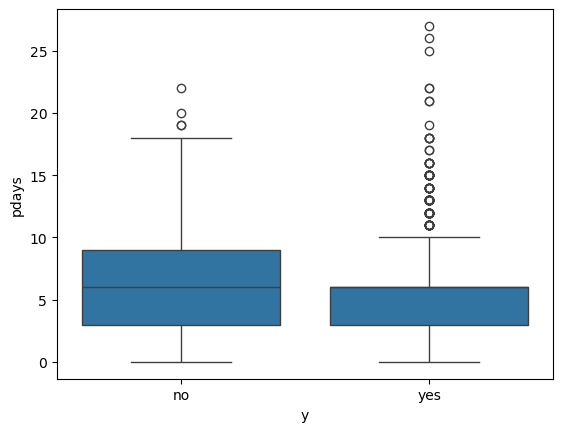

In [29]:
sns.boxplot(x='y', y='pdays', data=raw_df[raw_df['pdays'] != 999])

In [ ]:
raw_df.groupby('pdays')['y'].mean()

In [ ]:
sns.boxplot(x=raw_df["duration"], y='y')

## Scaling features
To answer if I should scale it, I will compare standard deviations and min/max values

- `duration`: min: 0, max: 4918

- `campaign`: min: 1, max: 56 

- `emp.var.rate`: min: -3.4, max: 1.4

- `cons.price.idx`: min: 92.2, max: 94.8

- `nr.employed`: min: 4963, max: 5228. 

For that I can see that the range is different for each column and it varies a lot. 

`Comparing standard deviations`


- `duration`: std ≈ 259

- `campaign`: std ≈ 2.77

- `emp.var.rate`: std ≈ 1.57

- `cons.price.idx`: std ≈ 0.58

- `nr.employed`: std ≈ 72

The standard deviations vary a lot across variables: from 0.58 to 259. 

I decided that scaling features is nessesary because it would prevent that some high-scaled variables would dominate in the model learning. 

I considered two options for scaling:  `StandardScaler()` and `MinMaxScaler()`. I decided to scale the data with `StandardScaler()` 

because it scales data based on mean and variance and since in the dataset several features contain outliers (and `MinMaxScaler()` is
 
sensitive to outliers) and  some features have skewness - `StandardScaler()` was my choice. 

In [14]:
raw_df['pdays'].unique()

array([999,   6,   4,   3,   5,   1,   0,  10,   7,   8,   9,  11,   2,
        12,  13,  14,  15,  16,  21,  17,  18,  22,  25,  26,  19,  27,
        20])

In [15]:
raw_df['previous'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

## Finding redundunt and correlated features

In [49]:
numeric_features, categorical_features = numeric_categorical_features(raw_df)

In [50]:
numeric_features

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [51]:
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

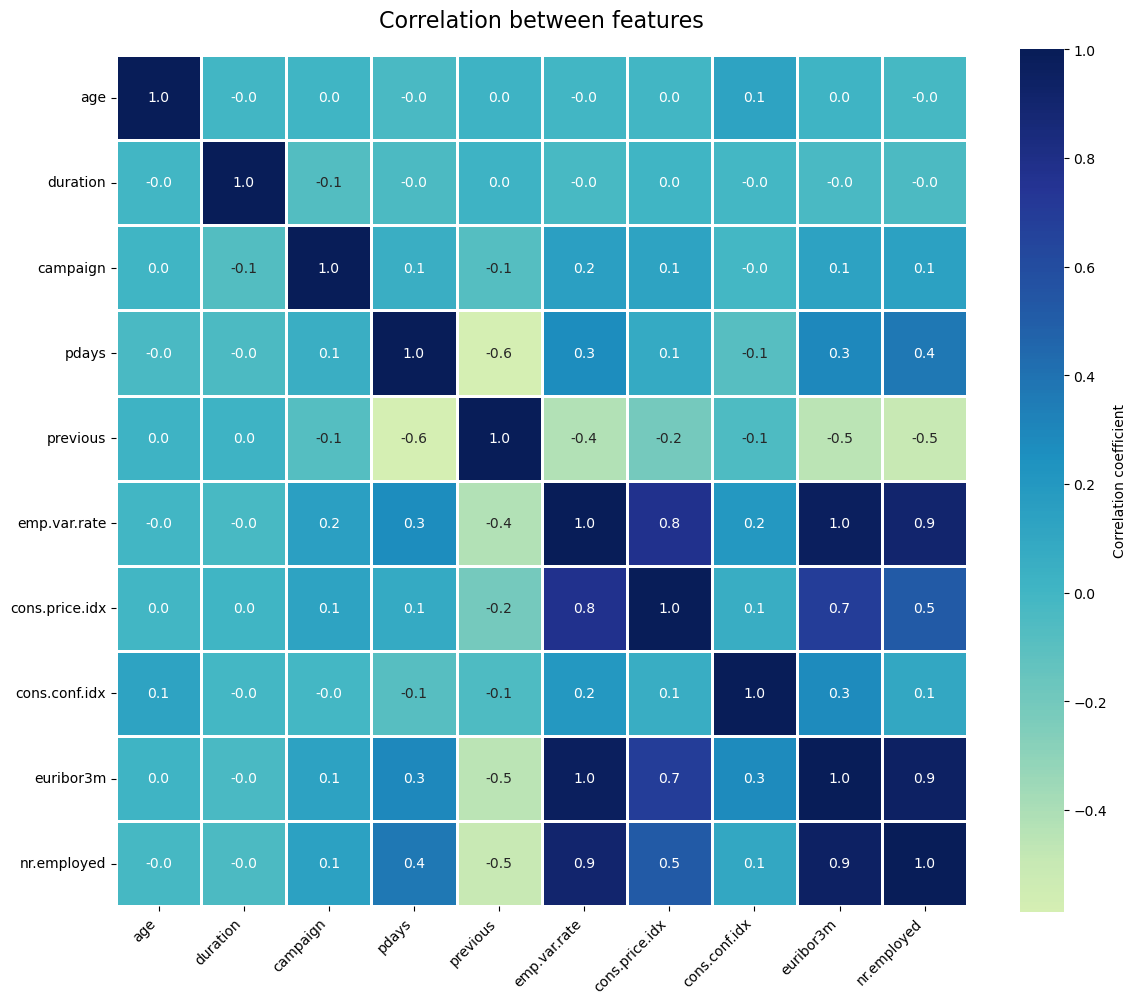

In [60]:
features_correlation(raw_df, numeric_features)

Based on the correlation matrix between numeric features, there are pairs of features which show high correlation:

  `euribor3m` correlated with `emp.var.rate`, correlation coefficient is 0.97

  `nr.employed` correlated with `euribor3m`, correlation coefficient is 0.95

  `nr.employed` correlated with `emp.var.rate`, correlation coefficient is 0.91
  
  `cons.price.idx` correlated with `emp.var.rate`: , correlation coefficient is 0.78

To further investigate the relationships beween  those correlated features, I plotted scatterplots

<Axes: xlabel='euribor3m', ylabel='emp.var.rate'>

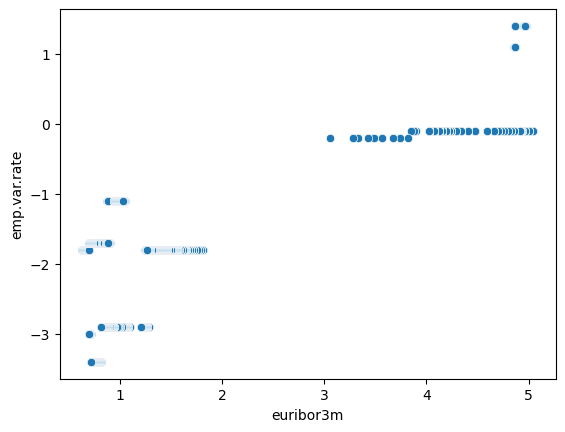

In [61]:
sns.scatterplot(data=raw_df, x="euribor3m", y="emp.var.rate")

I can see that these features carry the same information: when euribor3m is low (around 0.7–1.5), emp.var.rate is also low (negative, between −1.5 and −3.5).

When euribor3m is high (around 3–5), emp.var.rate is also high (near 0).

They rise and fall together, so knowing one tells the other.

<Axes: xlabel='nr.employed', ylabel='euribor3m'>

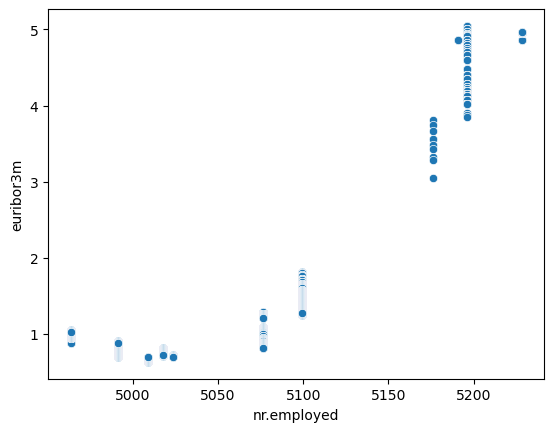

In [62]:
sns.scatterplot(data=raw_df, x="nr.employed", y="euribor3m")

The scatterplot of `nr.employed` and `euribor3m` shows the same pattern: low nr.employed always pairs with low `euribor3m`, and high `nr.employed` always pairs with high `euribor3m`.

One of these variables is redundant since they carry the same information.

<Axes: xlabel='nr.employed', ylabel='emp.var.rate'>

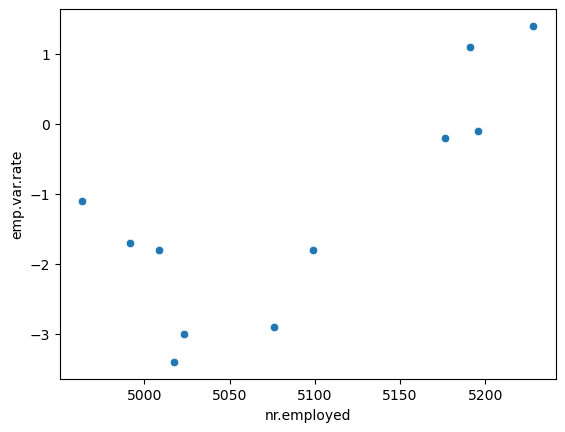

In [63]:
sns.scatterplot(data=raw_df, x="nr.employed", y="emp.var.rate")

The scatterplot of `nr.employed` and `emp.var.rate` looks different from the others — it shows only about 12 visible dots despite the dataset having tens of thousands of rows.

This is because both features are recorded once per month for the entire country, not per customer.
Every customer contacted in the same month gets the exact same value for both columns, so thousands of customers stack on top of each other at each dot.

<Axes: xlabel='euribor3m', ylabel='cons.price.idx'>

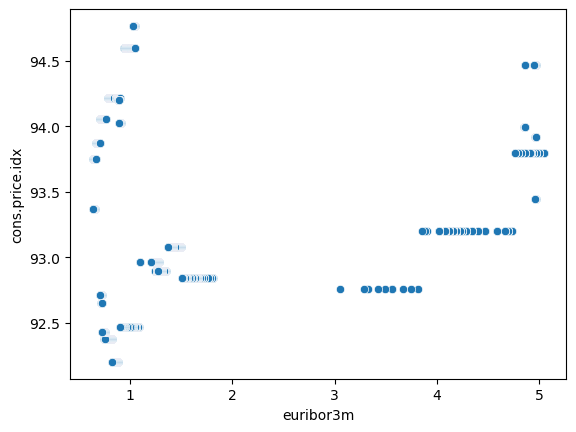

In [64]:
sns.scatterplot(data=raw_df, x="euribor3m", y="cons.price.idx")

The scatterplot of `euribor3m` and `cons.price.idx` shows that these two variables do not fully overlap.

At the same `euribor3m` value, `cons.price.idx` spreads across a wide range: I cannot predict one from the other.

The correlation of 0.78 between `cons.price.idx` and `emp.var.rate` is moderate, but the scatterplot shows enough independent variation to keep cons.price.idx as a separate feature.

All three features `euribor3m`, `emp.var.rate` and `nr.employed` carry overlapping information.

Since my goal is to introduce as less noise as possible, I keep only one feature: `euribor3m`. 

I decided to keep only `euribor3m`, because when `euribor3m` is high, term deposits offer better returns, so customers are more 

likely to say yes (and since that is the target variable the choice is obvious).